# Experiment 3: Regression Analysis using Linear and Regularized Models
**ICS1512 – Machine Learning Algorithms Laboratory**

Dataset: Loan Amount prediction (Kaggle "Predict Loan Amount Data")

In [1]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load Dataset

The Kaggle "Predict Loan Amount Data" zip contains `train.csv` and `test.csv`. Only `train.csv`
has the target column (`Loan Sanction Amount (USD)`) filled in -- `test.csv` is an unlabeled
Kaggle-submission file with no target, so it cannot be used to compute regression metrics. This
notebook therefore uses **`train.csv` only**, and creates its own train/test split from it (as the
lab manual requires for evaluation).

Place `train.csv` in the same folder as this notebook.

In [2]:
df = pd.read_csv("train.csv")
target = "Loan Sanction Amount (USD)"
id_cols = ["Customer ID", "Name", "Property ID"]
df = df.drop(columns=[c for c in id_cols if c in df.columns])
print(df.shape)
df.head()

(30000, 21)


,Gender,Age,Income (USD),Income Stability,Profession,Type of Employment,Location,Loan Amount Request (USD),Current Loan Expenses (USD),Expense Type 1,...,Dependents,Credit Score,No. of Defaults,Has Active Credit Card,Property Age,Property Type,Property Location,Co-Applicant,Property Price,Loan Sanction Amount (USD)
0,F,56,1933.05,Low,Working,Sales staff,Semi-Urban,72809.58,241.08,N,...,3.0,809.44,0,NaN,1933.05,4,Rural,1,119933.46,54607.18
1,M,32,4952.91,Low,Working,NaN,Semi-Urban,46837.47,495.81,N,...,1.0,780.40,0,Unpossessed,4952.91,2,Rural,1,54791.00,37469.98
2,F,65,988.19,High,Pensioner,NaN,Semi-Urban,45593.04,171.95,N,...,1.0,833.15,0,Unpossessed,988.19,2,Urban,0,72440.58,36474.43
3,F,65,NaN,High,Pensioner,NaN,Rural,80057.92,298.54,N,...,2.0,832.70,1,Unpossessed,NaN,2,Semi-Urban,1,121441.51,56040.54
4,F,31,2614.77,Low,Working,High skill tech staff,Semi-Urban,113858.89,491.41,N,...,NaN,745.55,1,Active,2614.77,4,Semi-Urban,1,208567.91,74008.28


## 2. Exploratory Data Analysis

In [3]:
print(df.shape)
df.info()
df.describe(include="all")

(30000, 21)
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Gender                       29947 non-null  str    
 1   Age                          30000 non-null  int64  
 2   Income (USD)                 25424 non-null  float64
 3   Income Stability             28317 non-null  str    
 4   Profession                   30000 non-null  str    
 5   Type of Employment           22730 non-null  str    
 6   Location                     30000 non-null  str    
 7   Loan Amount Request (USD)    30000 non-null  float64
 8   Current Loan Expenses (USD)  29828 non-null  float64
 9   Expense Type 1               30000 non-null  str    
 10  Expense Type 2               30000 non-null  str    
 11  Dependents                   27507 non-null  float64
 12  Credit Score                 28297 non-null  float64
 13  No. of Defaults

,Gender,Age,Income (USD),Income Stability,Profession,Type of Employment,Location,Loan Amount Request (USD),Current Loan Expenses (USD),Expense Type 1,...,Dependents,Credit Score,No. of Defaults,Has Active Credit Card,Property Age,Property Type,Property Location,Co-Applicant,Property Price,Loan Sanction Amount (USD)
count,29947,30000.000000,2.542400e+04,28317,30000,22730,30000,30000.000000,29828.000000,30000,...,27507.000000,28297.000000,30000.000000,28434,2.515000e+04,30000.000000,29644,30000.000000,3.000000e+04,29660.000000
unique,2,NaN,NaN,2,8,18,3,NaN,NaN,2,...,NaN,NaN,NaN,3,NaN,NaN,3,NaN,NaN,NaN
top,M,NaN,NaN,Low,Working,Laborers,Semi-Urban,NaN,NaN,N,...,NaN,NaN,NaN,Active,NaN,NaN,Semi-Urban,NaN,NaN,NaN
freq,15053,NaN,NaN,25751,16926,5578,21563,NaN,NaN,19214,...,NaN,NaN,NaN,9771,NaN,NaN,10387,NaN,NaN,NaN
mean,NaN,40.092300,2.630574e+03,NaN,NaN,NaN,NaN,88826.333855,400.936876,NaN,...,2.253027,739.885381,0.193933,NaN,2.631119e+03,2.460067,NaN,-4.743867,1.317597e+05,47649.342208
std,NaN,16.045129,1.126272e+04,NaN,NaN,NaN,NaN,59536.949605,242.545375,NaN,...,0.951162,72.163846,0.395384,NaN,1.132268e+04,1.118562,NaN,74.614593,9.354955e+04,48221.146686
min,NaN,18.000000,3.777000e+02,NaN,NaN,NaN,NaN,6048.240000,-999.000000,NaN,...,1.000000,580.000000,0.000000,NaN,3.777000e+02,1.000000,NaN,-999.000000,-9.990000e+02,-999.000000
25%,NaN,25.000000,1.650457e+03,NaN,NaN,NaN,NaN,41177.755000,247.667500,NaN,...,2.000000,681.880000,0.000000,NaN,1.650450e+03,1.000000,NaN,1.000000,6.057216e+04,0.000000
50%,NaN,40.000000,2.222435e+03,NaN,NaN,NaN,NaN,75128.075000,375.205000,NaN,...,2.000000,739.820000,0.000000,NaN,2.223250e+03,2.000000,NaN,1.000000,1.099936e+05,35209.395000
75%,NaN,55.000000,3.090593e+03,NaN,NaN,NaN,NaN,119964.605000,521.292500,NaN,...,3.000000,799.120000,0.000000,NaN,3.091408e+03,3.000000,NaN,1.000000,1.788807e+05,74261.250000


In [4]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Gender                           53
Age                               0
Income (USD)                   4576
Income Stability               1683
Profession                        0
Type of Employment             7270
Location                          0
Loan Amount Request (USD)         0
Current Loan Expenses (USD)     172
Expense Type 1                    0
Expense Type 2                    0
Dependents                     2493
Credit Score                   1703
No. of Defaults                   0
Has Active Credit Card         1566
Property Age                   4850
Property Type                     0
Property Location               356
Co-Applicant                      0
Property Price                    0
Loan Sanction Amount (USD)      340
dtype: int64


### Target variable distribution

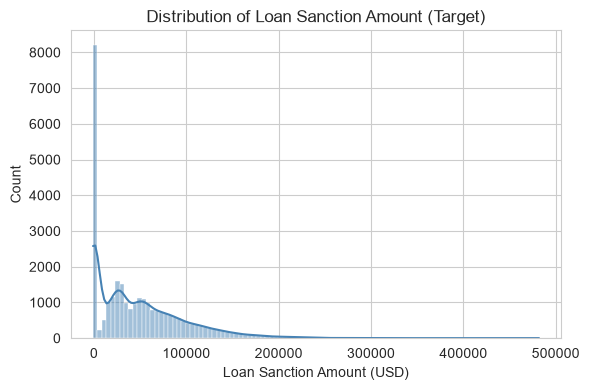

In [5]:
plt.figure(figsize=(6, 4))
sns.histplot(df[target].dropna(), kde=True, color="steelblue")
plt.title("Distribution of Loan Sanction Amount (Target)")
plt.xlabel(target)
plt.tight_layout()
plt.show()

### Feature vs. target scatter plots

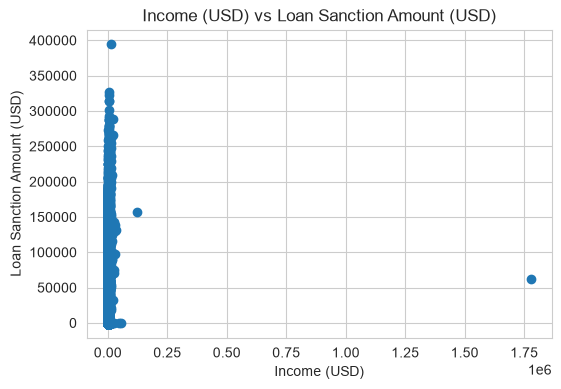

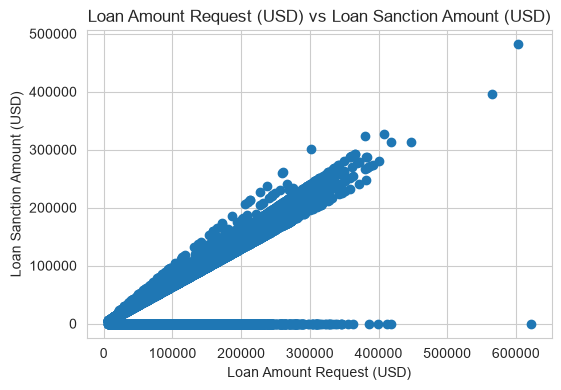

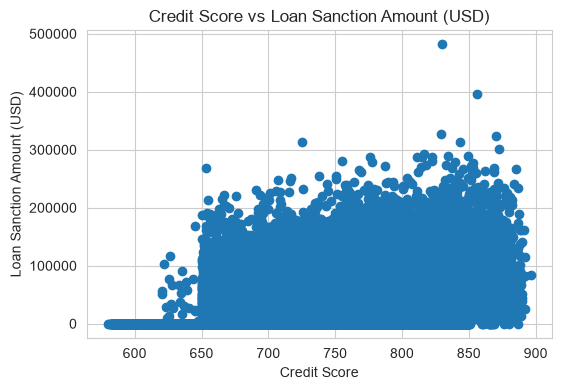

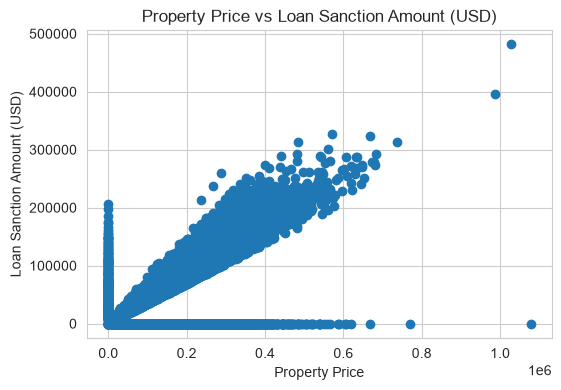

In [6]:
features = ["Income (USD)", "Loan Amount Request (USD)", "Credit Score", "Property Price"]

for feat in features:
    if feat in df.columns:
        plt.figure(figsize=(6,4))
        plt.scatter(df[feat], df[target])
        plt.xlabel(feat)
        plt.ylabel(target)
        plt.title(f"{feat} vs {target}")
        plt.show()

## 3. Data Preprocessing
- Handle missing values (median for numeric, mode for categorical)
- Encode categorical variables (one-hot encoding)
- Standardize numerical features

In [7]:
# Remove rows where the target value is missing
df = df.dropna(subset=[target])

# Fill missing values in numerical columns with the median
for column in df.select_dtypes(include='number').columns:
    if column != target:
        df[column] = df[column].fillna(df[column].median())

# Fill missing values in categorical columns with the mode
for column in df.select_dtypes(include='object').columns:
    df[column] = df[column].fillna(df[column].mode()[0])

# Convert categorical columns into numerical values
df_encoded = pd.get_dummies(df, drop_first=True)

# Separate features and target
X = df_encoded.drop(target, axis=1)
y = df_encoded[target]

# Display the size of the feature matrix
print("Feature matrix shape:", X.shape)

Feature matrix shape: (29660, 45)


C:\Users\tashw\AppData\Local\Temp\ipykernel_17204\1411131652.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in df.select_dtypes(include='object').columns:


In [8]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Scale
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X.columns,
    index=X_test.index
)

## 4. Baseline Linear Regression

In [9]:
start = time.time()
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
lin_train_time = time.time() - start

y_pred_lin = lin_reg.predict(X_test_scaled)
print(f"Training time: {lin_train_time:.4f}s")

Training time: 0.0900s


## 5. Hyperparameter Tuning (Ridge, Lasso, Elastic Net)
5-Fold Cross-Validation Grid Search over the specified hyperparameter grids.

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_grids = {
    "Ridge": {"alpha": [0.01, 0.1, 1, 10, 100]},
    "Lasso": {"alpha": [0.001, 0.01, 0.1, 1, 10]},
    "ElasticNet": {"alpha": [0.01, 0.1, 1, 10], "l1_ratio": [0.2, 0.5, 0.8]},
}

estimators = {
    "Ridge": Ridge(random_state=RANDOM_STATE),
    "Lasso": Lasso(random_state=RANDOM_STATE, max_iter=50000),
    "ElasticNet": ElasticNet(random_state=RANDOM_STATE, max_iter=50000),
}

best_models = {}
tuning_summary = []

for name, estimator in estimators.items():
    grid = GridSearchCV(
        estimator, param_grids[name], scoring="r2", cv=cv, n_jobs=-1
    )
    start = time.time()
    grid.fit(X_train_scaled, y_train)
    fit_time = time.time() - start

    best_models[name] = grid.best_estimator_
    tuning_summary.append({
        "Model": name,
        "Search Method": "Grid Search",
        "Best Parameters": grid.best_params_,
        "Best CV R2": grid.best_score_,
        "Training Time (s)": fit_time,
    })

tuning_df = pd.DataFrame(tuning_summary)
tuning_df

## 6. Train Final Models

In [ ]:

models = {
    "Linear Regression": lin_reg,
    "Ridge Regression": best_models["Ridge"],
    "Lasso Regression": best_models["Lasso"],
    "Elastic Net Regression": best_models["ElasticNet"]
}

y_pred_lin = lin_reg.predict(X_test)
y_pred_ridge = best_models["Ridge"].predict(X_test)
y_pred_lasso = best_models["Lasso"].predict(X_test)
y_pred_elastic = best_models["ElasticNet"].predict(X_test)

## 7. Cross-Validation Performance (K = 5)

In [ ]:
def cv_metrics(model, X, y, cv):
    mae = -cross_val_score(model, X, y, scoring="neg_mean_absolute_error", cv=cv).mean()
    mse = -cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=cv).mean()
    rmse = np.sqrt(mse)
    r2 = cross_val_score(model, X, y, scoring="r2", cv=cv).mean()
    return mae, mse, rmse, r2

cv_results = []
for name, model in models.items():
    mae, mse, rmse, r2 = cv_metrics(model, X_train_scaled, y_train, cv)
    cv_results.append({"Model": name, "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2})

cv_results_df = pd.DataFrame(cv_results)
cv_results_df

## 8. Test Set Performance

In [ ]:
test_results = []

for name, y_pred in [
    ("Linear Regression", y_pred_lin),
    ("Ridge Regression", y_pred_ridge),
    ("Lasso Regression", y_pred_lasso),
    ("Elastic Net Regression", y_pred_elastic)
]:
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    test_results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    })

test_results_df = pd.DataFrame(test_results)
test_results_df

### Test Set Performance Comparison

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(test_results_df["Model"], test_results_df["RMSE"], color="indianred")
axes[0].set_title("RMSE by Model")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(test_results_df["Model"], test_results_df["R2"], color="seagreen")
axes[1].set_title("R2 Score by Model")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## 9. Predicted vs. Actual and Residual Plots

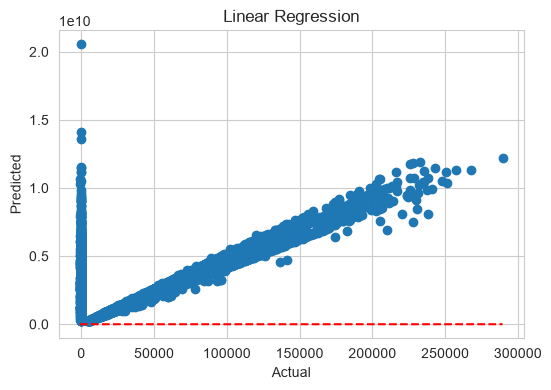

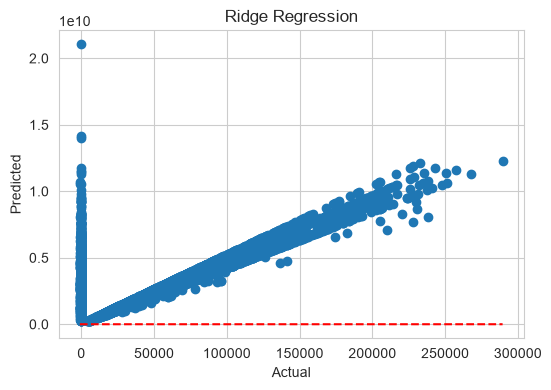

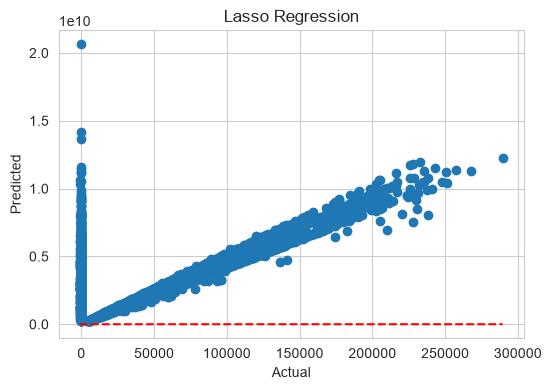

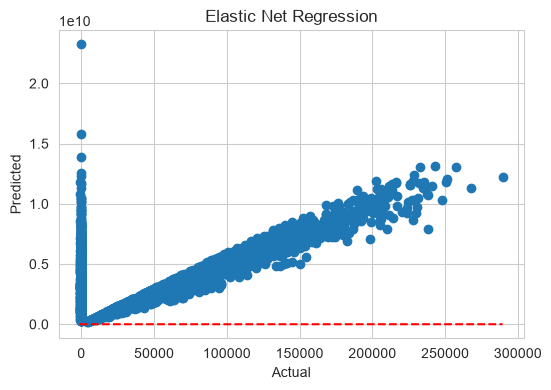

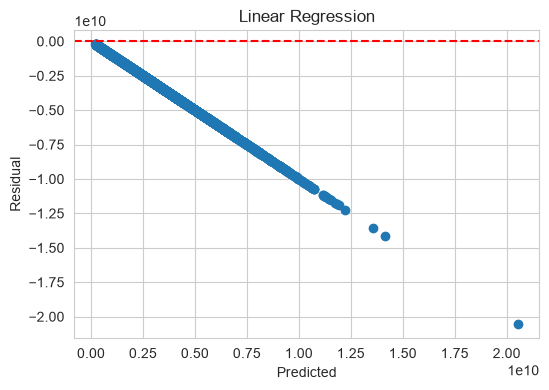

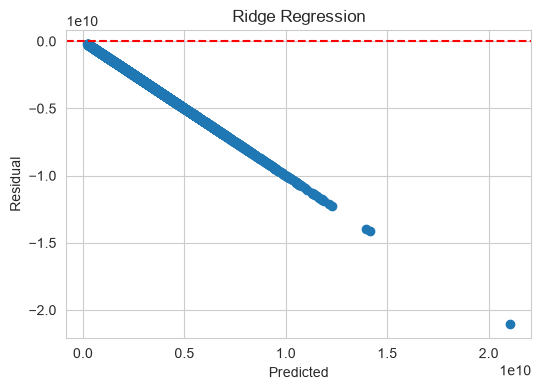

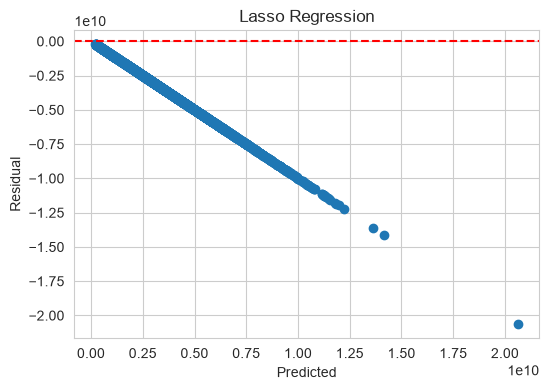

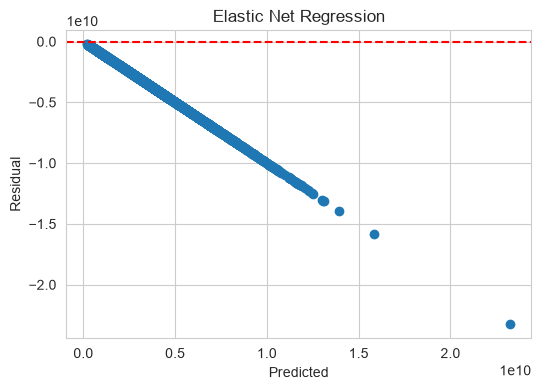

In [15]:
predictions = {
    "Linear Regression": y_pred_lin,
    "Ridge Regression": y_pred_ridge,
    "Lasso Regression": y_pred_lasso,
    "Elastic Net Regression": y_pred_elastic
}

for name, y_pred in predictions.items():

    plt.figure(figsize=(6,4))

    plt.scatter(y_test, y_pred)

    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--'
    )

    plt.title(name)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")

    plt.show()
for name, y_pred in predictions.items():

    residuals = y_test - y_pred

    plt.figure(figsize=(6,4))

    plt.scatter(y_pred, residuals)

    plt.axhline(y=0, color='red', linestyle='--')

    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Residual")

    plt.show()

## 10. Training Error vs. Validation Error (Overfitting/Underfitting)

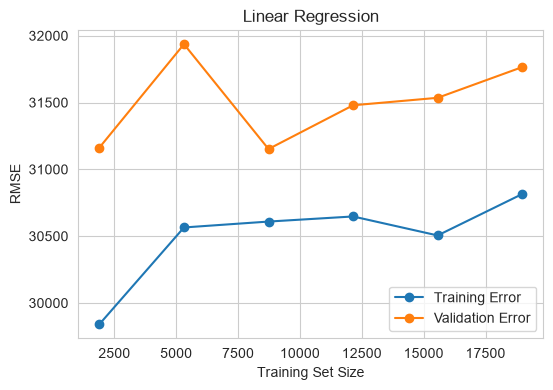

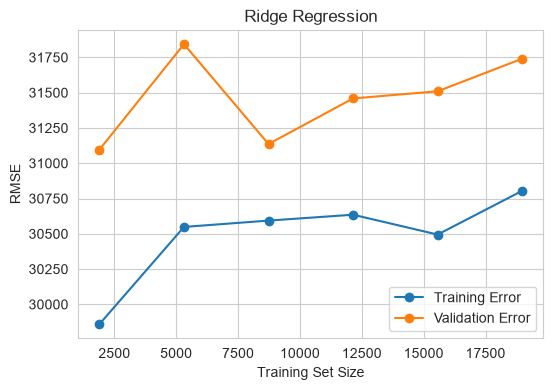

C:\Users\tashw\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.100959e+12, tolerance: 2.033e+09
  model = cd_fast.enet_coordinate_descent(
C:\Users\tashw\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.689122e+12, tolerance: 2.872e+09
  model = cd_fast.enet_coordinate_descent(
C:\Users\tashw\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consi

In [ ]:
from sklearn.model_selection import learning_curve

for name, model in models.items():

    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error",
        train_sizes=np.linspace(0.1, 1.0, 6)
    )

    train_error = -train_scores.mean(axis=1)
    val_error = -val_scores.mean(axis=1)

    plt.figure(figsize=(6,4))

    plt.plot(train_sizes, train_error, marker="o", label="Training Error")
    plt.plot(train_sizes, val_error, marker="o", label="Validation Error")

    plt.title(name)
    plt.xlabel("Training Set Size")
    plt.ylabel("RMSE")
    plt.legend()

    plt.show()

## 11. Effect of Regularization on Coefficients

In [ ]:
coef_df = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Linear": models["Linear Regression"].coef_,
    "Ridge": models["Ridge Regression"].coef_,
    "Lasso": models["Lasso Regression"].coef_,
    "Elastic Net": models["Elastic Net Regression"].coef_,
})

top_features = coef_df.reindex(
    coef_df["Linear"].abs().sort_values(ascending=False).index
).head(10)

top_features.set_index("Feature").plot(kind="bar", figsize=(14, 5))
plt.title("Coefficient Comparison Across Models (Top 10 Features by |Linear coef|)")
plt.ylabel("Coefficient value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

top_features

In [ ]:
n_nonzero = {
    "Linear": np.sum(models["Linear Regression"].coef_ != 0),
    "Ridge": np.sum(models["Ridge Regression"].coef_ != 0),
    "Lasso": np.sum(models["Lasso Regression"].coef_ != 0),
    "Elastic Net": np.sum(models["Elastic Net Regression"].coef_ != 0),
}
print("Number of non-zero coefficients per model:")
n_nonzero

## 12. Overfitting and Underfitting Analysis

- **Training vs. validation error:** compare the gap between the training and validation error
  curves above. A large gap (low training error, high validation error) indicates overfitting;
  high error on both indicates underfitting.
- **Effect of regularization strength:** larger `alpha` shrinks coefficients more aggressively,
  increasing bias but reducing variance. Small `alpha` behaves close to plain Linear Regression.
- **Improvement after tuning:** compare the CV R2 in the tuning summary table to the test R2 in the
  performance table — tuned Ridge/Lasso/Elastic Net should generalize better than an untuned model
  with an extreme alpha.

## 13. Bias–Variance Analysis

- **Linear Regression:** typically low bias, higher variance — fits training data closely but can
  be sensitive to noise and multicollinearity, hurting generalization.
- **Ridge / Elastic Net:** shrink coefficients (L2 penalty), trading a small increase in bias for a
  meaningful reduction in variance, usually improving test performance.
- **Lasso (and the L1 part of Elastic Net):** drives some coefficients exactly to zero, performing
  feature selection and increasing model sparsity, which can further reduce variance at the cost of
  bias if useful features are zeroed out.

## 14. Observations and Conclusion

Summarize, using the tables and plots above:
- Which model achieved the best test R2 / RMSE.
- The optimal hyperparameters found via Grid Search (Table 1 equivalent, `tuning_df`).
- Whether regularization improved generalization compared to plain Linear Regression.
- The trade-off observed between model accuracy and complexity (number of non-zero coefficients,
  training time).

In [ ]:
summary = test_results_df.sort_values("R2", ascending=False).reset_index(drop=True)
print("Final ranking by test R2:")
summary